# Week 18: Segmentation

Source: https://docs.ultralytics.com/models/sam-3#concept-segmentation-examples

In [1]:
%pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cpu
%pip install -q opencv-python matplotlib segment-anything requests transformers

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import torch
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os
import glob
import requests
import random
from tqdm import tqdm
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
from segment_anything import sam_model_registry, SamPredictor

CHECKPOINT_DIR = "checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Running on: {device}")



W0602 02:07:45.702000 32984 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


Running on: cpu


In [2]:
%pip install git+https://github.com/facebookresearch/segment-anything.git

  Cloning https://github.com/facebookresearch/segment-anything.git to c:\users\re72fam\appdata\local\temp\pip-req-build-27wi452o
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\re72fam\AppData\Local\Temp\pip-req-build-27wi452o'

[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from transformers import pipeline

pipeline = pipeline(
    "object-detection",
    model="facebook/detr-resnet-50"
)

Loading weights:   0%|          | 0/530 [00:00<?, ?it/s]

[transformers] DetrForObjectDetection LOAD REPORT from: facebook/detr-resnet-50
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
model.backbone.model.layer1.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer4.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer2.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 
model.backbone.model.layer3.0.downsample.1.num_batches_tracked | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
from ultralytics.models.sam import SAM3SemanticPredictor

# Initialize predictor with configuration
overrides = dict(
    conf=0.25,
    task="segment",
    mode="predict",
    model="sam3.pt",
    half=False,  # Use FP16 for faster inference
    save=True,
)
predictor = SAM3SemanticPredictor(overrides=overrides)

# Set image once for multiple queries
predictor.set_image("Pikachu.jpg")

# Query with multiple text prompts
results = predictor(text=["Pikachu"])

Ultralytics 8.4.53  Python-3.13.5 torch-2.11.0+cpu CPU (13th Gen Intel Core i9-13900H)
WARNING imgsz=[640] must be multiple of max stride 14, updating to [644]

image 1/1 c:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\Pikachu.jpg: 644x644 1 Pikachu, 753.0ms
Speed: 4.2ms preprocess, 753.0ms inference, 11.9ms postprocess per image at shape (1, 3, 644, 644)
Results saved to C:\Users\re72fam\Documents\winter 25-26\MLADCH2526\week18\runs\segment\predict-2


In [24]:
results[0].masks

ultralytics.engine.results.Masks object with attributes:

data: tensor([[[False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         ...,
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False],
         [False, False, False,  ..., False, False, False]]])
orig_shape: (192, 342)
shape: torch.Size([1, 192, 342])
xy: [array([[220., 148.],
       [220., 148.],
       [229.,  94.],
       [229.,  93.],
       [259.,  64.],
       [261.,  63.],
       [262.,  64.],
       [260.,  66.],
       [257.,  66.],
       [256.,  67.],
       [255.,  67.],
       [255.,  69.],
       [256.,  68.],
       [258.,  68.],
       [259.,  69.],
       [257.,  71.],
       [256.,  71.],
       [255.,  72.],
       [255.,  73.],
       [254.,  74.],
       [252.,  74.],
       [252.,  75.],
       [250.,  77.],
       [246.,  77.],
 

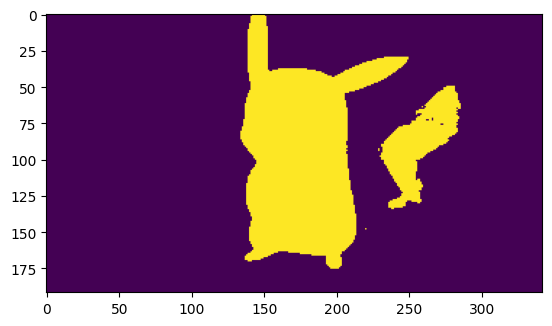

In [32]:
plt.imshow(results[0].masks.data.numpy()[0,:,:])

In [ ]:
best_box =results[0].masks.cpu().numpy()

# segementation withSAM
sam_predictor.set_image(image_rgb)

masks, scores, logits = sam_predictor.predict(
    box=best_box,
    multimask_output=False # We want the single best mask
)

return image, masks[0]

c:\Users\re72fam\AppData\Local\Programs\Python\Python313\Lib\site-packages\ultralytics\engine\results.py:173: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  return self.__class__(self.data[idx], self.orig_shape)


IndexError: too many indices for tensor of dimension 2

In [ ]:
plt.figure(figsize=(12, 6))

# Original_img
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis('off')

# Result
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
if mask is not None:
    # Overlay green mask
    masked_img = np.ma.masked_where(mask == 0, mask)
    plt.imshow(masked_img, alpha=0.6, cmap='Greens')
    plt.title("Detected 'Bone'")

In [4]:
# Load GroundingDINO (Detects box from text)
print("Loading GroundingDINO...")
dino_processor = AutoProcessor.from_pretrained("IDEA-Research/grounding-dino-base")
#dino_model = AutoModelForZeroShotObjectDetection.from_pretrained("IDEA-Research/grounding-dino-base").to(device)

# Download SAM Weights ( Segments inside box)
SAM_URL = "https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth"
SAM_CHECKPOINT = os.path.join(CHECKPOINT_DIR, "sam_vit_b_01ec64.pth")

if not os.path.exists(SAM_CHECKPOINT):
    print("Downloading SAM weights...")
    response = requests.get(SAM_URL, stream=True)
    with open(SAM_CHECKPOINT, 'wb') as f:
        for chunk in response.iter_content(chunk_size=1024):
            if chunk: f.write(chunk)
    print("Download complete.")

# Load SAM
print("Loading SAM...")
sam = sam_model_registry["vit_b"](checkpoint=SAM_CHECKPOINT)
sam.to(device=device)
sam_predictor = SamPredictor(sam)

print("Models Loaded Successfully!")

Loading GroundingDINO...


Loading SAM...
Models Loaded Successfully!


In [ ]:
## some of the bones only parts of it are captured
## Trying prompting "bones" instead of "bone"

In [6]:
# Segmentation Function (Text prompted)

def segment_bone_with_prompt(image_path, text_prompt="pikachu"):
    """
    Uses GroundingDINO to find the bounding box of 'text_prompt',
    then uses SAM to segment the object inside that box.
    """
    image = cv2.imread(image_path)
    if image is None: return None, None
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Detect Box with GroundingDINO
    inputs = dino_processor(images=image_rgb, text=f"{text_prompt}.", return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = dino_model(**inputs)
    
    # Post-process boxes
    target_sizes = torch.tensor([image_rgb.shape[:2]], device=device)
    
    # access the image_processor directly (fixing an error)
    if hasattr(dino_processor, "image_processor"):
         results = dino_processor.image_processor.post_process_object_detection(
            outputs, 
            threshold=0.35, 
            target_sizes=target_sizes
        )[0]
    else:
        # Fallback for older/different versions
        results = dino_processor.post_process_grounded_object_detection(
            outputs, 
            input_ids=inputs.input_ids,
            box_threshold=0.35,
            text_threshold=0.25,
            target_sizes=target_sizes
        )[0]

    
    if len(results["boxes"]) == 0:
        return image, None
        
    # to choose box with the highst confidence score
    best_box_idx = results["scores"].argmax()
    best_box = results["boxes"][best_box_idx].cpu().numpy()
    
    # segementation withSAM
    sam_predictor.set_image(image_rgb)
    
    masks, scores, logits = sam_predictor.predict(
        box=best_box,
        multimask_output=False # We want the single best mask
    )
    
    return image, masks[0]

In [3]:
# Testing on a random image

# Find all images
test_imgs = glob.glob("Pikachu.jpg", recursive=True)
# Filter processed ones
test_imgs = [p for p in test_imgs if "processed" not in p]

if test_imgs:
    p = random.choice(test_imgs)
    print(f"Testing on: {os.path.basename(p)}")
    
    img, mask = segment_bone_with_prompt(p, text_prompt="bone")
    
    plt.figure(figsize=(12, 6))
    
    # Original_img
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title("Original")
    plt.axis('off')
    
    # Result
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    if mask is not None:
        # Overlay green mask
        masked_img = np.ma.masked_where(mask == 0, mask)
        plt.imshow(masked_img, alpha=0.6, cmap='Greens')
        plt.title("Detected 'Bone'")
    else:
        plt.title("No Bone Found")
    plt.axis('off')
    plt.show()
else:
    print("No images found.")

Testing on: Pikachu.jpg


NameError: name 'dino_processor' is not defined

In [ ]:

# Bone Cutout

def create_bone_cutout(image, mask):
    if mask is None: return None
    
    # to uint8
    mask_uint8 = (mask * 255).astype(np.uint8)
    
    # to find Bounding Box of the mask (to crop empty space)
    contours, _ = cv2.findContours(mask_uint8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    
    # bounding box of the largest contour (the bone)
    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)
    
    # small padding (shape fixing)
    pad = 10
    h_img, w_img = image.shape[:2]
    x1 = max(0, x - pad)
    y1 = max(0, y - pad)
    x2 = min(w_img, x + w + pad)
    y2 = min(h_img, y + h + pad)
    
    # Crop Image and Mask
    img_crop = image[y1:y2, x1:x2]
    mask_crop = mask_uint8[y1:y2, x1:x2]
    
    # Create BGRA Image and convert BGR to BGRA with cv
    img_bgra = cv2.cvtColor(img_crop, cv2.COLOR_BGR2BGRA)
    
    # Set Alpha channel to the mask
    img_bgra[:, :, 3] = mask_crop
    
    return img_bgra

# test
if 'img' in locals() and 'mask' in locals() and mask is not None:
    cutout = create_bone_cutout(img, mask)
    
    if cutout is not None:
        plt.figure(figsize=(8, 8))
        # converting (matplotlib works with RGBA)
        plt.imshow(cv2.cvtColor(cutout, cv2.COLOR_BGRA2RGBA))
        plt.title("Final Bone Cutout (Transparent)")
        plt.axis('off')
        plt.show()
        
        cv2.imwrite("test_bone_cutout.png", cutout)
        print("Saved test_bone_cutout.png")
    else:
        print("Could not create cutout.")


Testing on: \\nas.ads.mwn.de\re98kof\MWN-PC\Dokumente\Sarrah_JupyterNotebooks\data\Pelvis 2D images\Pelvis 2D images\Achilleos 11\ID 2310-112\2310-112 LEFT\2310-112 L-1  (1).JPG


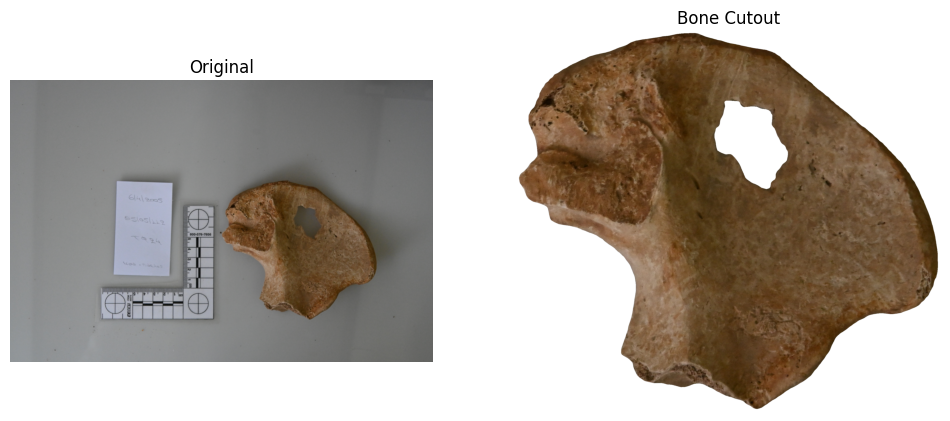

In [ ]:
# Testing on "\\nas.ads.mwn.de\re98kof\MWN-PC\Dokumente\Sarrah_JupyterNotebooks\data\Pelvis 2D images\Pelvis 2D images\Achilleos 11\ID 2310-112\2310-112 LEFT\2310-112 L-1  (1).JPG"

target_path = r"\\nas.ads.mwn.de\re98kof\MWN-PC\Dokumente\Sarrah_JupyterNotebooks\data\Pelvis 2D images\Pelvis 2D images\Achilleos 11\ID 2310-112\2310-112 LEFT\2310-112 L-1  (1).JPG"

print(f"Testing on: {target_path}")

if os.path.exists(target_path):
    # 1. Segment
    img, mask = segment_bone_with_prompt(target_path, text_prompt="bone")
    
    if mask is not None:
        # 2. Cutout
        cutout = create_bone_cutout(img, mask)
        
        # 3. Visualize
        plt.figure(figsize=(12, 6))
        
        plt.subplot(1, 2, 1)
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title("Original")
        plt.axis('off')
        
        plt.subplot(1, 2, 2)
        if cutout is not None:
            plt.imshow(cv2.cvtColor(cutout, cv2.COLOR_BGRA2RGBA))
            plt.title("Bone Cutout")
        else:
            plt.title("Cutout Failed")
        plt.axis('off')
        plt.show()
    else:
        print("Bone detection failed.")
else:
    print("Error: File not found. Check the path.")

In [ ]:
#Package installation 

%pip install --upgrade pip setuptools wheel
%pip install torch==2.7.0 torchvision torchaudio --index-url https://download.pytorch.org/whl/cu126

%git clone https://github.com/facebookresearch/sam3.git
%cd sam3

%pip install -e .
%pip install -e ".[notebooks]"

#Setting up huggingface to download the model weight

#Important: for the notebook to run you need to make a huggingface account, ask for access to sam3 folder https://huggingface.co/facebook/sam3, and get your token from your profile
%huggingface-cli login --token 'TOKEN'

  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 15.8 MB/s eta 0:00:00
Using cached setuptools-82.0.1-py3-none-any.whl (1.0 MB)
Using cached wheel-0.47.0-py3-none-any.whl (32 kB)

   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
   ---------------------------------------- 0/3 [wheel]
  Attempting uninstall: setuptools
   ---------------------------------------- 0/3 [wheel]
    Found existing installation: setuptools 81.0.0
   ---------------------------------------- 0/3 [wheel]
    Uninstalling setuptools-81.0.0:
   ---------------------------------------- 0/3 [wheel]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -------------------------- 1/3 [setuptools]
   ------------- -----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.11.0 requires setuptools<82, but you have setuptools 82.0.1 which is incompatible.


Looking in indexes: https://download.pytorch.org/whl/cu126
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/2.8 GB ? eta -:--:--
   ---------------------------------------- 0.0/2.8 GB 31.5 MB/s eta 0:01:28
   ---------------------------------------- 0.0/2.8 GB 46.0 MB/s eta 0:01:00
   ---------------------------------------- 0.0/2.8 GB 50.8 MB/s eta 0:00:54
    --------------------------------------- 0.0/2.8 GB 47.1 MB/s eta 0:00:59
    --------------------------------------- 0.0/2.8 GB 41.0 MB/s eta 0:01:07
    --------------------------------------- 0.0/2.8 GB 37.2 MB/s eta 0:01:14
    --------------------------------------- 0.1/2.8 GB 34.3 MB/s eta 0:01:20
    ---------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  You can safely remove it manually.
  You can safely remove it manually.
UsageError: Line magic function `%git` not found.


UsageError: Line magic function `%hf` not found.
